In [1]:
# CELL 1: SETUP & IMPORTS
import os
import time
import json
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Buat folder untuk menyimpan semua hasil agar tidak berantakan
SAVE_DIR = "results_exp3_group"
os.makedirs(SAVE_DIR, exist_ok=True)

# Cek ketersediaan GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")
if torch.cuda.is_available():
    print(f"Nama GPU: {torch.cuda.get_device_name(0)}")

Menggunakan device: cuda
Nama GPU: NVIDIA GeForce RTX 5070


In [2]:
# CELL 2: FOCAL LOSS
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce_loss = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        ce_loss = self.ce_loss(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [3]:
# CELL 3: DATASET & STRATIFIED K-FOLD (UPDATED LOCAL PATHS)
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import StratifiedGroupKFold

# 1. Kunci Lokasi Data Lokal
data_dir = r"C:\Users\asfan\Data\ham10000\full"
csv_path = r"C:\Users\asfan\Data\ham10000\HAM10000_metadata.csv"

# 2. Baca Metadata dan Petakan Kelas
df = pd.read_csv(csv_path)
class_names = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
class_to_idx = {c: i for i, c in enumerate(class_names)}

# Mapping kelas teks ('dx') menjadi indeks angka
df['label'] = df['dx'].map(class_to_idx)

# Membangun full path untuk setiap gambar secara otomatis
# Asumsi format gambar adalah .jpg dan nama file sama dengan image_id
df['image_path'] = df.apply(lambda row: os.path.join(data_dir, row['dx'], f"{row['image_id']}.jpg"), axis=1)

# Verifikasi path (Cek apakah gambar pertama benar-benar ada)
print(f"Total data: {len(df)}")
print(f"Contoh path gambar: {df.iloc[0]['image_path']}")
if not os.path.exists(df.iloc[0]['image_path']):
    print("WARNING: Path gambar tidak ditemukan! Pastikan ekstensi .jpg atau nama folder sesuai.")

# 3. Class Dataset Kustom
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        label = self.dataframe.iloc[idx]['label']
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# 4. Augmentasi Data
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 5. Persiapan Stratified 5-Fold
X = df['image_path'].values
y = df['label'].values
# TAMBAHAN: Ambil kolom lesion_id sebagai dasar pengelompokan subjek/pasien
groups = df['lesion_id'].values 

# BERUBAH: Menggunakan StratifiedGroupKFold
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

print("Dataset dan Stratified Group K-Fold siap!")

Total data: 10015
Contoh path gambar: C:\Users\asfan\Data\ham10000\full\bkl\ISIC_0027419.jpg
Dataset dan Stratified Group K-Fold siap!


In [4]:
# CELL 4 (REVISI UNTUK EXP 3): ConvNeXt + CBAM Attention
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
           
        self.fc = nn.Sequential(
            nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        out = avg_out + max_out
        return self.sigmoid(out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv1(x)
        return self.sigmoid(x)

class CBAM(nn.Module):
    def __init__(self, channels, ratio=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.ca = ChannelAttention(channels, ratio)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

class ConvNeXt_CBAM_Attention(nn.Module):
    def __init__(self, num_classes=7):
        super(ConvNeXt_CBAM_Attention, self).__init__()
        convnext = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
        self.features = convnext.features
        
        # Injeksi CBAM
        self.cbam = CBAM(channels=768)
        
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(1),
            nn.LayerNorm(768, eps=1e-6),
            nn.Linear(768, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x) # Proses Channel + Spatial secara berurutan
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

In [5]:
# CELL 5: TRAINING ENGINE WITH METRIC TRACKING & EPOCH TIMER
def train_model(fold, model, train_loader, val_loader, criterion, optimizer, num_epochs=50):
    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    start_time_total = time.time()
    torch.cuda.reset_peak_memory_stats()
    
    for epoch in range(num_epochs):
        epoch_start_time = time.time() # Mulai hitung waktu per epoch
        
        # --- TRAINING PHASE ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data)
            total += labels.size(0)
            
        epoch_train_loss = running_loss / total
        epoch_train_acc = correct.double() / total
        
        # --- VALIDATION PHASE ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += torch.sum(preds == labels.data)
                val_total += labels.size(0)
                
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct.double() / val_total
        
        # Hitung durasi epoch
        epoch_end_time = time.time()
        duration = epoch_end_time - epoch_start_time
        minutes = int(duration // 60)
        seconds = int(duration % 60)
        
        # Simpan metrik ke history
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc.item())
        history['val_acc'].append(epoch_val_acc.item())
        
        # Output sesuai permintaan (ditambah durasi)
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f} - {minutes} menit {seconds} detik")
        
        # Simpan model terbaik (.pth) - Update ke exp3
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            model_save_path = os.path.join(SAVE_DIR, f"exp3_fold{fold}_best_model.pth")
            torch.save(model.state_dict(), model_save_path)
            
    # Kalkulasi performa total
    end_time_total = time.time()
    training_time_total = end_time_total - start_time_total
    max_memory = torch.cuda.max_memory_allocated() / (1024 ** 2) 
    
    # Simpan history ke JSON
    with open(os.path.join(SAVE_DIR, f"exp3_fold{fold}_history.json"), 'w') as f:
        json.dump(history, f)
        
    return history, training_time_total, max_memory

In [6]:
# CELL 6: EVALUATION & REPORTING
def evaluate_and_plot(fold, model, val_loader, history, training_time, max_memory, class_names):
    # Load model terbaik
    model.load_state_dict(torch.load(os.path.join(SAVE_DIR, f"exp3_fold{fold}_best_model.pth")))
    model.eval()
    
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # 1. Classification Report & Metrics
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(os.path.join(SAVE_DIR, f"exp3_fold{fold}_classification_report.csv"))
    
    # Simpan resource metrik
    resource_log = {
        'training_time_seconds': training_time,
        'max_gpu_memory_mb': max_memory,
        'overall_accuracy': accuracy_score(all_labels, all_preds)
    }
    with open(os.path.join(SAVE_DIR, f"exp3_fold{fold}_resources.json"), 'w') as f:
        json.dump(resource_log, f)
        
    # 2. Plot Loss & Accuracy Curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_title(f'Loss Curve - Fold {fold}')
    ax1.legend()
    
    ax2.plot(history['train_acc'], label='Train Acc')
    ax2.plot(history['val_acc'], label='Val Acc')
    ax2.set_title(f'Accuracy Curve - Fold {fold}')
    ax2.legend()
    plt.savefig(os.path.join(SAVE_DIR, f"exp3_fold{fold}_learning_curves.png"))
    plt.show()
    
    # 3. Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(os.path.join(SAVE_DIR, f"exp3_fold{fold}_confusion_matrix.png"))
    plt.show()
    
    print(f"Semua log dan grafik untuk Fold {fold} berhasil disimpan di folder: {SAVE_DIR}")

# CONTOH EKSEKUSI (Bisa diletakkan di dalam loop Stratified K-Fold)
# class_names = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']
# criterion = FocalLoss(gamma=2)
# optimizer = optim.Adam(model.parameters(), lr=1e-4)
# history, t_time, max_mem = train_model(fold=1, model=model, train_loader=train_loader, val_loader=val_loader, criterion=criterion, optimizer=optimizer)
# evaluate_and_plot(fold=1, model=model, val_loader=val_loader, history=history, training_time=t_time, max_memory=max_mem, class_names=class_names)

Mulai Eksperimen 3: ConvNeXt + CBAM + Focal Loss + Group KFold
Menyimpan di folder: results_exp3_group

---> Memulai Fold 1 <---
Epoch 1/50 - Train Loss: 0.3711 Acc: 0.7589 | Val Loss: 0.2598 Acc: 0.8208 - 2 menit 14 detik
Epoch 2/50 - Train Loss: 0.2008 Acc: 0.8406 | Val Loss: 0.2298 Acc: 0.8376 - 2 menit 11 detik
Epoch 3/50 - Train Loss: 0.1337 Acc: 0.8831 | Val Loss: 0.2374 Acc: 0.8342 - 2 menit 13 detik
Epoch 4/50 - Train Loss: 0.0967 Acc: 0.9098 | Val Loss: 0.2479 Acc: 0.8406 - 2 menit 11 detik
Epoch 5/50 - Train Loss: 0.0727 Acc: 0.9289 | Val Loss: 0.2530 Acc: 0.8466 - 2 menit 11 detik
Epoch 6/50 - Train Loss: 0.0544 Acc: 0.9454 | Val Loss: 0.2938 Acc: 0.8332 - 2 menit 11 detik
Epoch 7/50 - Train Loss: 0.0663 Acc: 0.9360 | Val Loss: 0.2589 Acc: 0.8525 - 2 menit 11 detik
Epoch 8/50 - Train Loss: 0.0310 Acc: 0.9661 | Val Loss: 0.2656 Acc: 0.8426 - 2 menit 10 detik
Epoch 9/50 - Train Loss: 0.0247 Acc: 0.9723 | Val Loss: 0.2613 Acc: 0.8530 - 2 menit 10 detik
Epoch 10/50 - Train Loss:

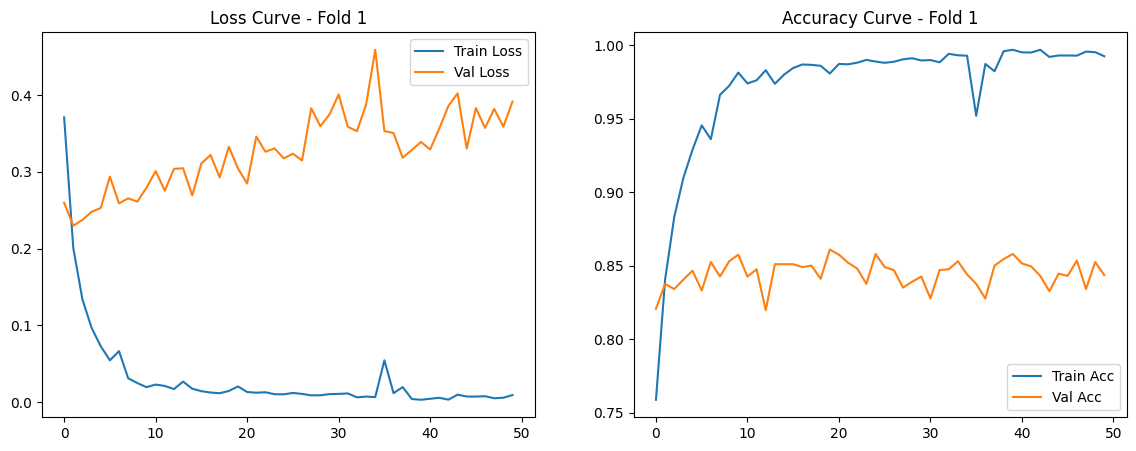

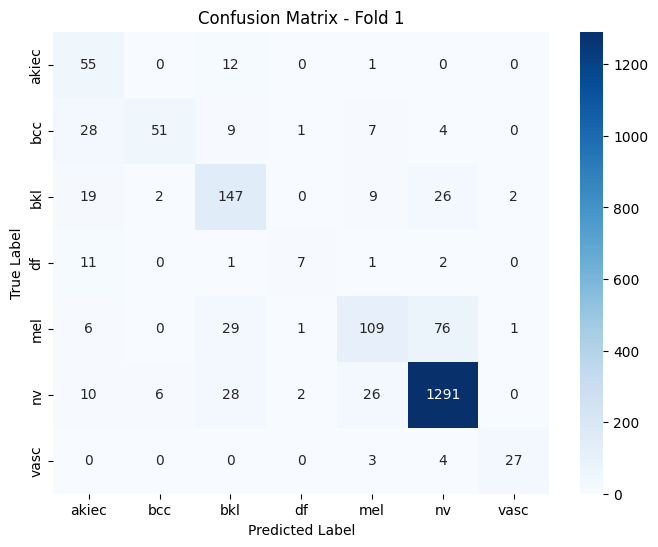

Semua log dan grafik untuk Fold 1 berhasil disimpan di folder: results_exp3_group

---> Memulai Fold 2 <---
Epoch 1/50 - Train Loss: 0.3877 Acc: 0.7543 | Val Loss: 0.2741 Acc: 0.7972 - 2 menit 10 detik
Epoch 2/50 - Train Loss: 0.2050 Acc: 0.8421 | Val Loss: 0.2493 Acc: 0.8102 - 2 menit 10 detik
Epoch 3/50 - Train Loss: 0.1399 Acc: 0.8835 | Val Loss: 0.2484 Acc: 0.8388 - 2 menit 10 detik
Epoch 4/50 - Train Loss: 0.1098 Acc: 0.8975 | Val Loss: 0.2044 Acc: 0.8498 - 2 menit 10 detik
Epoch 5/50 - Train Loss: 0.0767 Acc: 0.9269 | Val Loss: 0.1879 Acc: 0.8543 - 2 menit 10 detik
Epoch 6/50 - Train Loss: 0.0560 Acc: 0.9459 | Val Loss: 0.2048 Acc: 0.8568 - 2 menit 10 detik
Epoch 7/50 - Train Loss: 0.0440 Acc: 0.9562 | Val Loss: 0.2293 Acc: 0.8548 - 2 menit 10 detik
Epoch 8/50 - Train Loss: 0.0372 Acc: 0.9601 | Val Loss: 0.2540 Acc: 0.8373 - 2 menit 10 detik
Epoch 9/50 - Train Loss: 0.0312 Acc: 0.9677 | Val Loss: 0.2226 Acc: 0.8663 - 2 menit 10 detik
Epoch 10/50 - Train Loss: 0.0234 Acc: 0.9767 |

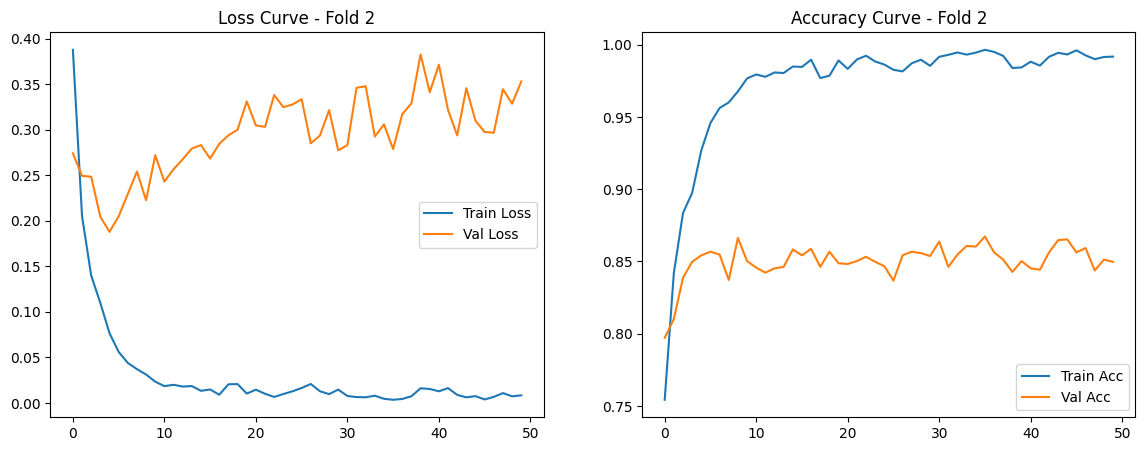

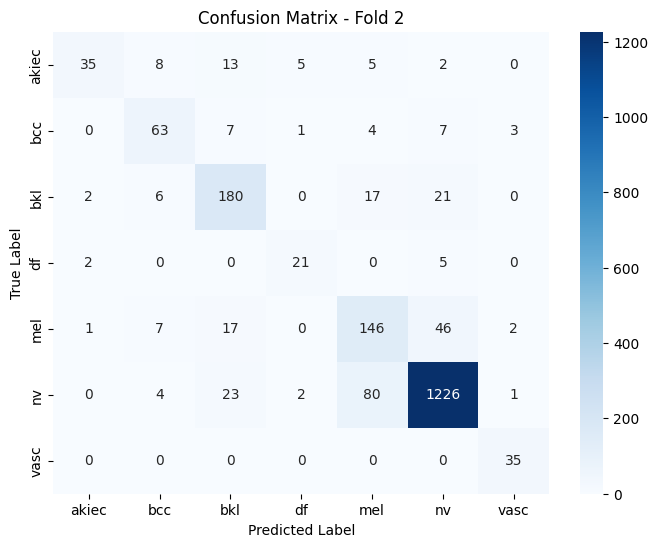

Semua log dan grafik untuk Fold 2 berhasil disimpan di folder: results_exp3_group

---> Memulai Fold 3 <---
Epoch 1/50 - Train Loss: 0.3788 Acc: 0.7460 | Val Loss: 0.2966 Acc: 0.8080 - 2 menit 10 detik
Epoch 2/50 - Train Loss: 0.1916 Acc: 0.8468 | Val Loss: 0.2163 Acc: 0.8353 - 2 menit 9 detik
Epoch 3/50 - Train Loss: 0.1450 Acc: 0.8775 | Val Loss: 0.2541 Acc: 0.8279 - 2 menit 9 detik
Epoch 4/50 - Train Loss: 0.1106 Acc: 0.8986 | Val Loss: 0.2054 Acc: 0.8478 - 2 menit 9 detik
Epoch 5/50 - Train Loss: 0.0703 Acc: 0.9300 | Val Loss: 0.2354 Acc: 0.8388 - 2 menit 9 detik
Epoch 6/50 - Train Loss: 0.0468 Acc: 0.9534 | Val Loss: 0.2584 Acc: 0.8463 - 2 menit 10 detik
Epoch 7/50 - Train Loss: 0.0471 Acc: 0.9530 | Val Loss: 0.2622 Acc: 0.8348 - 2 menit 10 detik
Epoch 8/50 - Train Loss: 0.0343 Acc: 0.9644 | Val Loss: 0.2473 Acc: 0.8463 - 2 menit 10 detik
Epoch 9/50 - Train Loss: 0.0262 Acc: 0.9721 | Val Loss: 0.2553 Acc: 0.8483 - 2 menit 10 detik
Epoch 10/50 - Train Loss: 0.0211 Acc: 0.9778 | Val

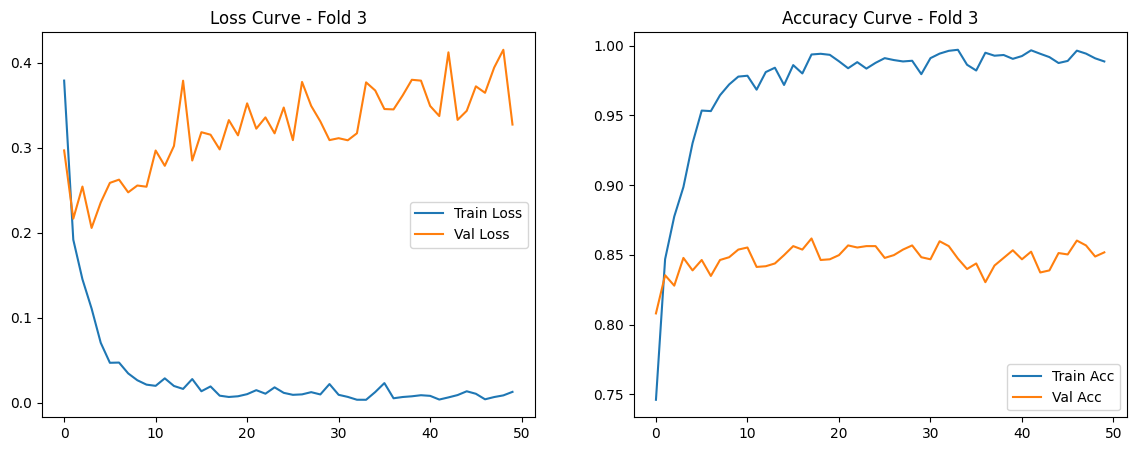

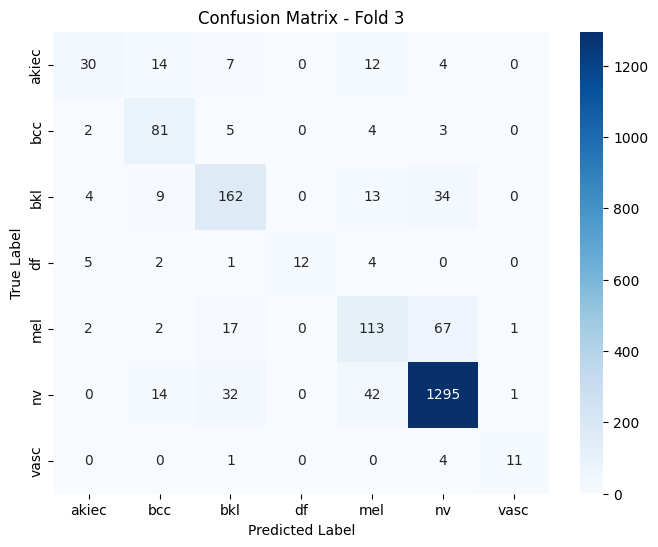

Semua log dan grafik untuk Fold 3 berhasil disimpan di folder: results_exp3_group

---> Memulai Fold 4 <---
Epoch 1/50 - Train Loss: 0.3804 Acc: 0.7594 | Val Loss: 0.2835 Acc: 0.7949 - 2 menit 9 detik
Epoch 2/50 - Train Loss: 0.1991 Acc: 0.8429 | Val Loss: 0.2355 Acc: 0.8227 - 2 menit 10 detik
Epoch 3/50 - Train Loss: 0.1392 Acc: 0.8820 | Val Loss: 0.2502 Acc: 0.8138 - 2 menit 10 detik
Epoch 4/50 - Train Loss: 0.0972 Acc: 0.9103 | Val Loss: 0.2194 Acc: 0.8282 - 2 menit 10 detik
Epoch 5/50 - Train Loss: 0.0712 Acc: 0.9268 | Val Loss: 0.2235 Acc: 0.8396 - 2 menit 10 detik
Epoch 6/50 - Train Loss: 0.0511 Acc: 0.9468 | Val Loss: 0.2178 Acc: 0.8446 - 2 menit 10 detik
Epoch 7/50 - Train Loss: 0.0384 Acc: 0.9596 | Val Loss: 0.2337 Acc: 0.8520 - 2 menit 10 detik
Epoch 8/50 - Train Loss: 0.0277 Acc: 0.9694 | Val Loss: 0.2396 Acc: 0.8386 - 2 menit 9 detik
Epoch 9/50 - Train Loss: 0.0351 Acc: 0.9625 | Val Loss: 0.2567 Acc: 0.8267 - 2 menit 10 detik
Epoch 10/50 - Train Loss: 0.0293 Acc: 0.9693 | V

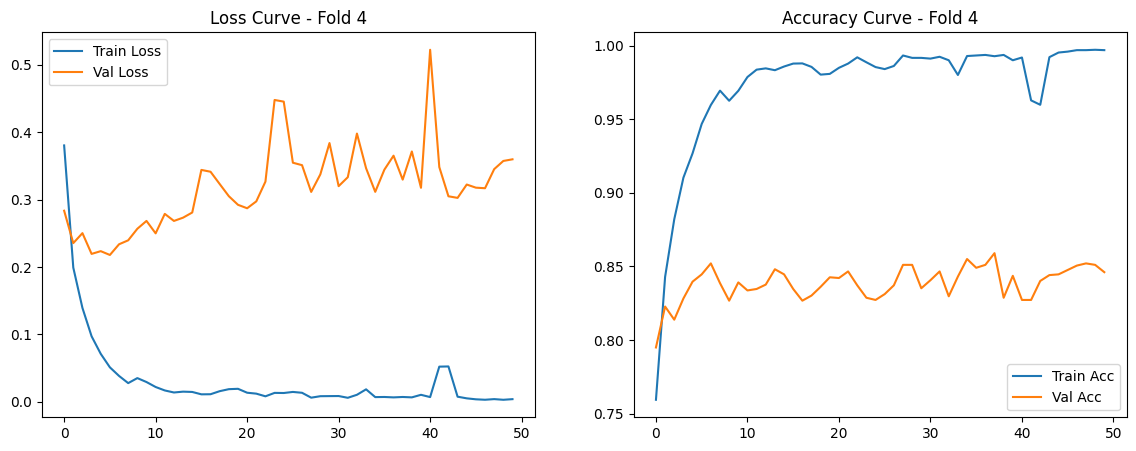

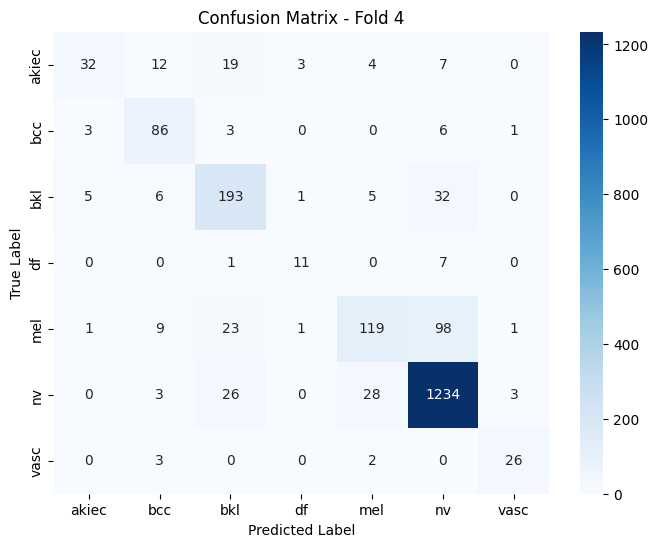

Semua log dan grafik untuk Fold 4 berhasil disimpan di folder: results_exp3_group

---> Memulai Fold 5 <---
Epoch 1/50 - Train Loss: 0.4199 Acc: 0.7434 | Val Loss: 0.2728 Acc: 0.8071 - 2 menit 11 detik
Epoch 2/50 - Train Loss: 0.2078 Acc: 0.8348 | Val Loss: 0.2237 Acc: 0.8364 - 2 menit 9 detik
Epoch 3/50 - Train Loss: 0.1472 Acc: 0.8772 | Val Loss: 0.2261 Acc: 0.8404 - 2 menit 10 detik
Epoch 4/50 - Train Loss: 0.1025 Acc: 0.9024 | Val Loss: 0.2110 Acc: 0.8586 - 2 menit 10 detik
Epoch 5/50 - Train Loss: 0.0775 Acc: 0.9238 | Val Loss: 0.2051 Acc: 0.8530 - 2 menit 10 detik
Epoch 6/50 - Train Loss: 0.0542 Acc: 0.9482 | Val Loss: 0.2047 Acc: 0.8591 - 2 menit 10 detik
Epoch 7/50 - Train Loss: 0.0389 Acc: 0.9579 | Val Loss: 0.2185 Acc: 0.8601 - 2 menit 9 detik
Epoch 8/50 - Train Loss: 0.0335 Acc: 0.9654 | Val Loss: 0.2634 Acc: 0.8500 - 2 menit 11 detik
Epoch 9/50 - Train Loss: 0.0338 Acc: 0.9663 | Val Loss: 0.2527 Acc: 0.8535 - 2 menit 10 detik
Epoch 10/50 - Train Loss: 0.0249 Acc: 0.9737 | V

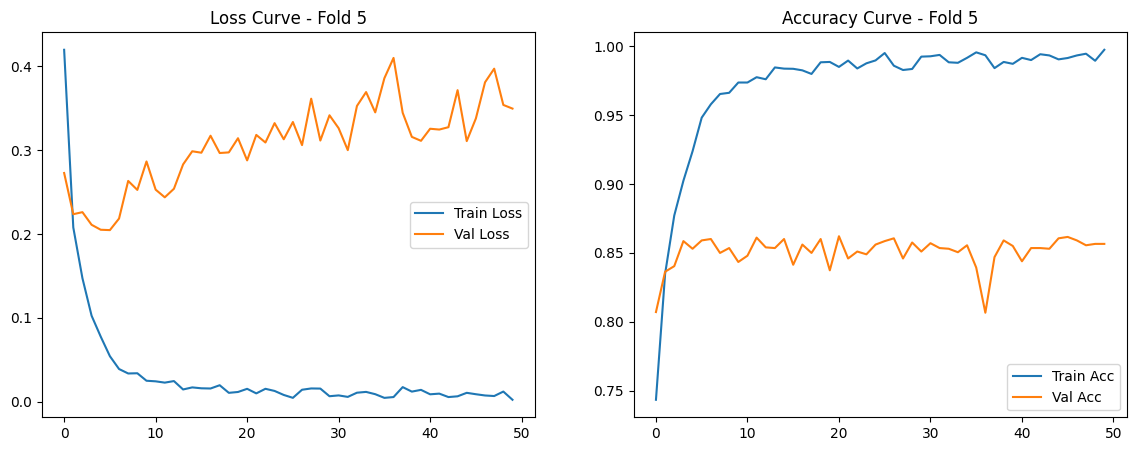

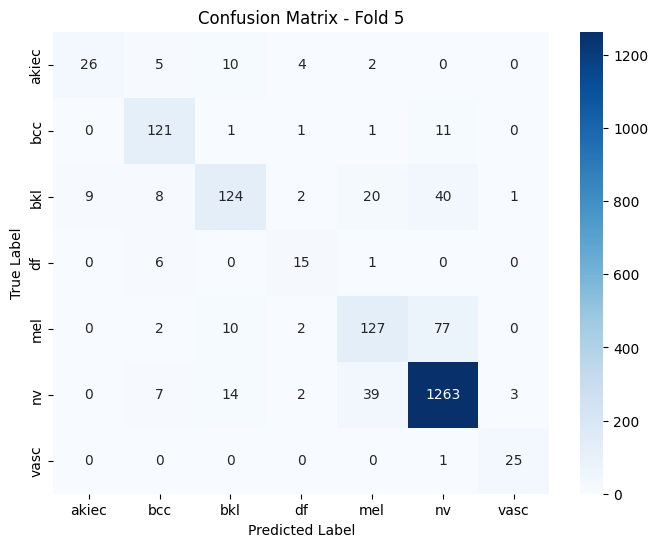

Semua log dan grafik untuk Fold 5 berhasil disimpan di folder: results_exp3_group

ALHAMDULILLAH, EKSPERIMEN 3 SELESAI TOTAL!
Semua grafik, metric, dan file .pth telah diamankan.


In [7]:
# CELL 7: MASTER EXECUTION LOOP (RUN EXPERIMENT 1)
import torch.optim as optim

# Hyperparameters
BATCH_SIZE = 64
NUM_EPOCHS = 50
LEARNING_RATE = 1e-4

print(f"Mulai Eksperimen 3: ConvNeXt + CBAM + Focal Loss + Group KFold")
print(f"Menyimpan di folder: {SAVE_DIR}\n" + "="*50)

#for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups=groups), 1):
    print(f"\n---> Memulai Fold {fold} <---")
    
    # Bagi dataframe berdasarkan index fold
    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]
    
    # Buat Dataset dan DataLoader
    train_dataset = HAM10000Dataset(train_df, transform=train_transform)
    val_dataset = HAM10000Dataset(val_df, transform=val_transform)
    
    # Gunakan num_workers=4 atau 8 jika CPU Xeon Anda mendukung untuk mempercepat I/O
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # Inisialisasi Ulang Model dan Optimizer untuk setiap Fold
    model = ConvNeXt_CBAM_Attention(num_classes=7).to(device)
    criterion = FocalLoss(gamma=2) # Mengatasi Imbalance
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    # Mulai Training
    history, t_time, max_mem = train_model(
        fold=fold, 
        model=model, 
        train_loader=train_loader, 
        val_loader=val_loader, 
        criterion=criterion, 
        optimizer=optimizer, 
        num_epochs=NUM_EPOCHS
    )
    
    # Mulai Evaluasi & Plotting
    evaluate_and_plot(
        fold=fold, 
        model=model, 
        val_loader=val_loader, 
        history=history, 
        training_time=t_time, 
        max_memory=max_mem, 
        class_names=class_names
    )
    
print("\n" + "="*50)
print("ALHAMDULILLAH, EKSPERIMEN 3 SELESAI TOTAL!")
print("Semua grafik, metric, dan file .pth telah diamankan.")

In [8]:
# CELL 8: SUMMARY CALCULATOR (MEAN & STD) - FIXED VERSION
import os
import pandas as pd
import glob

# Pastikan path folder benar sesuai hasil running tadi
class_names = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
results_path = "results_exp3_group"
csv_files = glob.glob(os.path.join(results_path, "exp3_fold*_classification_report.csv"))

if len(csv_files) < 5:
    print(f"Peringatan: Baru ditemukan {len(csv_files)} file CSV. Pastikan 5 fold sudah selesai running semua.")
else:
    all_reports = []
    
    for file in csv_files:
        # Perbaikan: index_col=0 digunakan agar kolom pertama (nama kelas) jadi index
        df_fold = pd.read_csv(file, index_col=0) 
        all_reports.append(df_fold)
    
    # Gabungkan semua fold
    full_concat = pd.concat(all_reports)
    
    # Hitung rata-rata (Mean) dan Standar Deviasi (Std)
    mean_report = full_concat.groupby(full_concat.index).mean()
    std_report = full_concat.groupby(full_concat.index).std()

    # Mengambil metrik utama (Accuracy dan Macro F1)
    # Note: Di report sklearn, accuracy biasanya ada di baris 'accuracy' kolom 'precision'
    mean_accuracy = mean_report.loc['accuracy', 'precision']
    mean_macro_f1 = mean_report.loc['macro avg', 'f1-score']
    
    std_accuracy = std_report.loc['accuracy', 'precision']
    std_macro_f1 = std_report.loc['macro avg', 'f1-score']
    
    print("="*50)
    print("   HASIL AKHIR EKSPERIMEN 2 (STATISTIK 5-FOLD)")
    print("="*50)
    print(f"Mean Accuracy : {mean_accuracy:.4f} ± {std_accuracy:.4f}")
    print(f"Mean Macro F1 : {mean_macro_f1:.4f} ± {std_macro_f1:.4f}")
    print("-" * 50)
    
    # Tampilkan tabel lengkap rata-rata per kelas agar bisa langsung di-copy ke Paper
    print("\nLaporan Lengkap (Mean Performance per Class):")
    target_rows = class_names + ['macro avg', 'weighted avg']
    summary_table = mean_report.loc[target_rows, ['precision', 'recall', 'f1-score']]
    
    # Menampilkan tabel
    from IPython.display import display
    display(summary_table)
    
    # Simpan hasil akhir ke CSV untuk arsip
    summary_table.to_csv(os.path.join(results_path, "EXP3_FINAL_SUMMARY_STATISTICS.csv"))
    print(f"\n[INFO] Laporan final telah disimpan di: {results_path}/EXP2_FINAL_SUMMARY_STATISTICS.csv")

   HASIL AKHIR EKSPERIMEN 2 (STATISTIK 5-FOLD)
Mean Accuracy : 0.8487 ± 0.0084
Mean Macro F1 : 0.7223 ± 0.0389
--------------------------------------------------

Laporan Lengkap (Mean Performance per Class):


,precision,recall,f1-score
akiec,0.704475,0.548013,0.585700
bcc,0.755804,0.773758,0.751496
bkl,0.725724,0.729725,0.724807
df,0.724985,0.565789,0.616265
mel,0.660146,0.554371,0.595840
nv,0.915508,0.941044,0.927891
vasc,0.860118,0.856373,0.854245
macro avg,0.763823,0.709868,0.722320
weighted avg,0.849271,0.848672,0.844621



[INFO] Laporan final telah disimpan di: results_exp3_group/EXP2_FINAL_SUMMARY_STATISTICS.csv
